# SC2001 Project 1: Hybrid Merge Sort and Insertion Sort

This notebook is a reproducible lab record for parts **(a)**, **(b)**, **(c)(i)**, **(c)(ii)**, **(c)(iii)**, and **(d)** of Project 1.

The focus is algorithm analysis: **key comparisons**, asymptotic reasoning, the effect of threshold $S$, and CPU time only where it helps select a practical threshold or where part (d) explicitly requires it. The two merge-sort implementations share the same merge procedure and differ meaningfully only at the base case:

> If the current subarray has size at most $S$, sort it with insertion sort; otherwise continue merge-sort recursion.

No library sorting routine is used by either algorithm. No parallelism, JIT compilation, vectorization, hardware-specific tuning, or alternative high-performance implementation is used.

## Assignment-to-notebook map

| Project part | Notebook section |
|---|---|
| (a) Implement hybrid algorithm | Algorithm implementation and correctness checks |
| (b) Generate increasing random datasets | Dataset generation and experimental controls |
| (c)(i) Fixed $S$, varying $n$ | Experiment 1 |
| (c)(ii) Fixed $n$, varying $S$ | Experiment 2 |
| (c)(iii) Determine an appropriate $S$ for different $n$ | Experiment 3 |
| (d) Compare with original Merge Sort on 10,000,000 integers | Final comparison |


In [1]:
from __future__ import annotations

import gc
import math
import platform
import random
import statistics
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

SEED = 2001
MAX_VALUE = 10_000_000

pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Python {sys.version.split()[0]} on {platform.platform()}")
print(f"Random seed = {SEED:,}; generated values are in [1, {MAX_VALUE:,}]")


Python 3.13.5 on Windows-11-10.0.26200-SP0
Random seed = 2,001; generated values are in [1, 10,000,000]


## (a) Algorithm implementation

### Pseudocode

```text
HYBRID-MERGE-SORT(A, left, right, S)
    size = right - left + 1
    if size <= S
        INSERTION-SORT(A, left, right)
        return
    mid = floor((left + right) / 2)
    HYBRID-MERGE-SORT(A, left, mid, S)
    HYBRID-MERGE-SORT(A, mid + 1, right, S)
    MERGE(A, left, mid, right)
```

The original Merge Sort uses the same recursion and the same `merge` routine. Its only algorithmic difference is the ordinary one-element base case.

### Counting rule

A **key comparison** compares two input values:

- `values[i] <= values[j]` in `merge`, or
- `values[j] > key` in insertion sort.

Index/boundary checks, arithmetic, assignments, and loop-control checks are not key comparisons. In insertion sort, a value comparison is counted only when `j >= left`, so a short-circuited boundary check does not inflate the count.


In [2]:
def insertion_sort_range(values: list[int], left: int, right: int) -> int:
    comparisons = 0
    for i in range(left + 1, right + 1):
        key = values[i]
        j = i - 1
        while j >= left:
            comparisons += 1
            if values[j] <= key:
                break
            values[j + 1] = values[j]
            j -= 1
        values[j + 1] = key
    return comparisons


def merge(values: list[int], auxiliary: list[int], left: int, mid: int, right: int) -> int:
    for position in range(left, right + 1):
        auxiliary[position] = values[position]

    i, j = left, mid + 1
    comparisons = 0

    for destination in range(left, right + 1):
        if i > mid:
            values[destination] = auxiliary[j]
            j += 1
        elif j > right:
            values[destination] = auxiliary[i]
            i += 1
        else:
            comparisons += 1
            if auxiliary[i] <= auxiliary[j]:
                values[destination] = auxiliary[i]
                i += 1
            else:
                values[destination] = auxiliary[j]
                j += 1
    return comparisons


def merge_sort(values: list[int]) -> int:
    auxiliary = [0] * len(values)

    def sort(left: int, right: int) -> int:
        if left >= right:
            return 0
        mid = (left + right) // 2
        comparisons = sort(left, mid)
        comparisons += sort(mid + 1, right)
        comparisons += merge(values, auxiliary, left, mid, right)
        return comparisons

    return sort(0, len(values) - 1)


def hybrid_merge_sort(values: list[int], threshold: int) -> int:
    if threshold < 1:
        raise ValueError("threshold must be at least 1")
    auxiliary = [0] * len(values)

    def sort(left: int, right: int) -> int:
        size = right - left + 1
        if size <= threshold:
            return insertion_sort_range(values, left, right)
        mid = (left + right) // 2
        comparisons = sort(left, mid)
        comparisons += sort(mid + 1, right)
        comparisons += merge(values, auxiliary, left, mid, right)
        return comparisons

    return 0 if not values else sort(0, len(values) - 1)


In [3]:
def is_sorted(values: list[int]) -> bool:
    return all(values[i - 1] <= values[i] for i in range(1, len(values)))


test_cases = [
    [], [7], [2, 1], [3, 1, 2], [4, 1, 4, 2, 0],
    list(range(20)), list(range(19, -1, -1)),
]

for case in test_cases:
    expected = sorted(case)  # Used only as a test oracle, never by the algorithms.
    ordinary = case.copy()
    merge_sort(ordinary)
    assert ordinary == expected
    for threshold in (1, 2, 4, 8, 32):
        hybrid = case.copy()
        hybrid_merge_sort(hybrid, threshold)
        assert hybrid == expected

# With S = 1, the hybrid follows exactly the same recursion and merge operations.
rng = random.Random(SEED)
sample = [rng.randint(1, 100) for _ in range(1_001)]
a, b = sample.copy(), sample.copy()
ordinary_count = merge_sort(a)
hybrid_count = hybrid_merge_sort(b, 1)
assert a == b and ordinary_count == hybrid_count

print("Correctness checks passed, including structural equivalence at S = 1.")


Correctness checks passed, including structural equivalence at S = 1.


## Theoretical analysis

Let $n$ be the input size and suppose recursion stops when subarrays have size about $S$.

There are about $\log_2(n/S)$ merge levels above the insertion-sorted leaves. Each merge level uses at most a linear number of key comparisons, so the merging contribution is

$$\Theta\left(n\log_2\frac{n}{S}\right).$$

There are about $n/S$ leaves. Insertion sort takes $\Theta(S^2)$ comparisons in the average and worst cases for a leaf of size $S$, so all leaves together contribute

$$\frac{n}{S}\Theta(S^2)=\Theta(nS).$$

Therefore,

$$T(n,S)=\Theta\left(n\log_2\frac{n}{S}+nS\right).$$

For a fixed constant $S$, this remains $\Theta(n\log n)$. Increasing $S$ removes merge levels, reducing the first term, but makes the insertion-sorted leaves more expensive, increasing the second term. For random distinct values, insertion sort performs roughly $S^2/4$ key comparisons per full leaf on average, making the trade-off visible before the asymptotic worst-case bound dominates.

For original Merge Sort, the worst-case comparison recurrence is

$$C(n)=C(\lfloor n/2\rfloor)+C(\lceil n/2\rceil)+(n-1),$$

which gives $\Theta(n\log n)$. When $n$ is a power of two, the worst-case count is exactly $n\log_2 n-n+1$.

CPU time is not identical to comparison count: replacing several recursive calls and small merges with a simple insertion-sort loop can reduce overhead even if it performs slightly more key comparisons. That explains why the comparison-minimising $S$ and time-minimising $S$ need not match.


## (b) Dataset generation and experimental controls

- Values are pseudorandom integers drawn uniformly from $[1, 10{,}000{,}000]$.
- A fixed seed makes the experiment reproducible.
- Every comparison across algorithms or thresholds starts from a copy of the **same unsorted dataset**.
- Comparison experiments use one deterministic run because the count itself has no timing noise.
- CPU experiments report the median of three runs in part (c)(iii). Part (d) uses one run per algorithm because each run sorts 10 million integers; both algorithms still receive the same data.
- `time.process_time()` measures CPU time rather than wall-clock time.

The increasing-size study reaches 1,000,000 elements, and part (d) separately fulfils the required 10,000,000-element comparison. This avoids turning the intermediate plots into an unnecessarily long benchmarking exercise.


In [4]:
def make_dataset(n: int, seed: int) -> list[int]:
    rng = random.Random(seed)
    return [rng.randint(1, MAX_VALUE) for _ in range(n)]


def run_sort(algorithm, source: list[int], *args) -> tuple[int, float]:
    working = source.copy()
    start = time.process_time()
    comparisons = algorithm(working, *args)
    cpu_seconds = time.process_time() - start
    assert is_sorted(working)
    del working
    return comparisons, cpu_seconds


## (c)(i) Fixed $S$, varying input size $n$

**Question:** With $S$ fixed, does the empirical comparison count grow as $\Theta(n\log n)$?

We use $S=16$ as a representative small constant. Dividing comparisons by $n\log_2 n$ should produce a roughly stable ratio as $n$ grows if the theoretical model is appropriate.


,n,S,key_comparisons,comparisons / (n log2 n)
0,1000,16,10413,1.044875
1,2000,16,22598,1.030387
2,5000,16,58584,0.953538
3,10000,16,127112,0.956613
4,20000,16,274483,0.960556
5,50000,16,770552,0.987277
6,100000,16,1638368,0.986396
7,200000,16,3478148,0.987569
8,500000,16,9609207,1.015152
9,1000000,16,20223321,1.014638


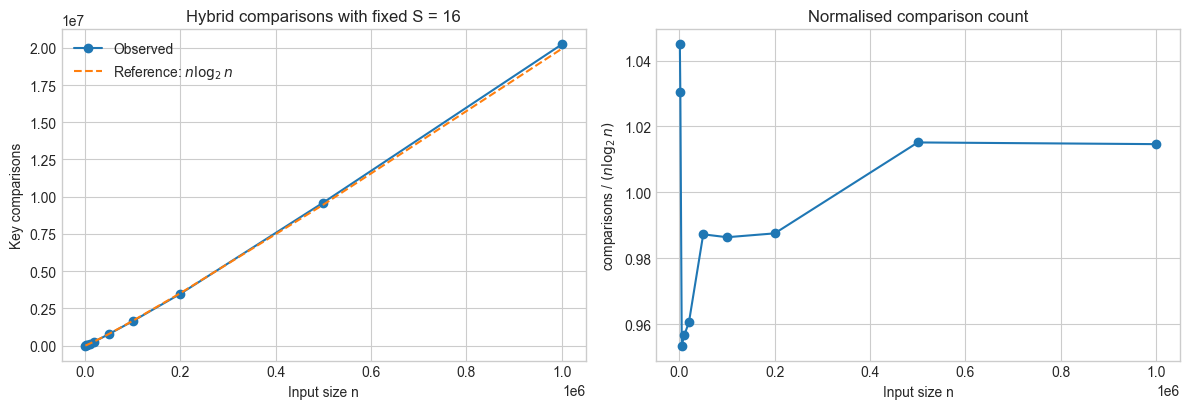

Interpretation: the normalised ratio stays within [0.954, 1.045]. This empirical stability supports Theta(n log n) growth when S is fixed.


In [5]:
FIXED_S = 16
SIZES_C1 = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000,
            100_000, 200_000, 500_000, 1_000_000]

c1_rows = []
for n in SIZES_C1:
    data = make_dataset(n, SEED + n)
    comparisons, _ = run_sort(hybrid_merge_sort, data, FIXED_S)
    c1_rows.append({
        "n": n,
        "S": FIXED_S,
        "key_comparisons": comparisons,
        "comparisons / (n log2 n)": comparisons / (n * math.log2(n)),
    })
    del data
    gc.collect()

c1 = pd.DataFrame(c1_rows)
display(c1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(c1["n"], c1["key_comparisons"], marker="o", label="Observed")
axes[0].plot(c1["n"], c1["n"] * c1["n"].map(math.log2), linestyle="--", label=r"Reference: $n\log_2n$")
axes[0].set(xlabel="Input size n", ylabel="Key comparisons", title=f"Hybrid comparisons with fixed S = {FIXED_S}")
axes[0].legend()

axes[1].plot(c1["n"], c1["comparisons / (n log2 n)"], marker="o")
axes[1].set(xlabel="Input size n", ylabel=r"comparisons / $(n\log_2 n)$", title="Normalised comparison count")
plt.tight_layout()
plt.show()

print(
    "Interpretation: the normalised ratio stays within "
    f"[{c1['comparisons / (n log2 n)'].min():.3f}, "
    f"{c1['comparisons / (n log2 n)'].max():.3f}]. "
    "This empirical stability supports Theta(n log n) growth when S is fixed."
)


## (c)(ii) Fixed $n$, varying $S$

**Question:** How does changing $S$ affect key comparisons when the input is fixed?

The same unsorted array is used for every threshold. Small increases in $S$ can remove merge levels, but large values make the quadratic insertion-sort work within each leaf dominate. We expect a shallow minimum at a small threshold followed by increasing comparisons.


,n,S,key_comparisons
0,200000,1,3272851
1,200000,2,3272851
2,200000,4,3273283
3,200000,8,3315694
4,200000,16,3478396
5,200000,32,3922280
6,200000,64,4962322
7,200000,128,7222622
8,200000,256,11903097


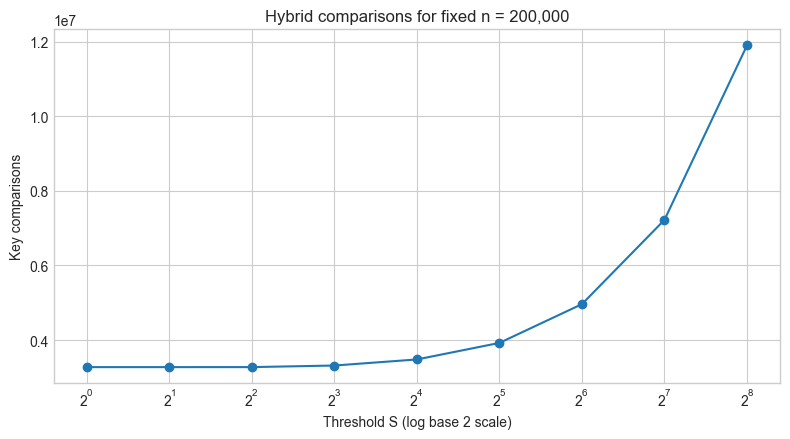

Fewest key comparisons in this experiment: S = 1.
Interpretation: increasing S removes merge work but adds insertion-sort work. After the minimum, the growing leaf cost dominates, consistent with Theta(n log(n/S) + nS).


8794

In [6]:
FIXED_N = 200_000
S_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
fixed_data = make_dataset(FIXED_N, SEED + 20_000_000)

c2_rows = []
for threshold in S_VALUES:
    comparisons, _ = run_sort(hybrid_merge_sort, fixed_data, threshold)
    c2_rows.append({"n": FIXED_N, "S": threshold, "key_comparisons": comparisons})

c2 = pd.DataFrame(c2_rows)
display(c2)

plt.figure(figsize=(8, 4.5))
plt.plot(c2["S"], c2["key_comparisons"], marker="o")
plt.xscale("log", base=2)
plt.xlabel("Threshold S (log base 2 scale)")
plt.ylabel("Key comparisons")
plt.title(f"Hybrid comparisons for fixed n = {FIXED_N:,}")
plt.tight_layout()
plt.show()

comparison_best_s = int(c2.loc[c2["key_comparisons"].idxmin(), "S"])
print(f"Fewest key comparisons in this experiment: S = {comparison_best_s}.")
print(
    "Interpretation: increasing S removes merge work but adds insertion-sort work. "
    "After the minimum, the growing leaf cost dominates, consistent with "
    "Theta(n log(n/S) + nS)."
)

del fixed_data
gc.collect()


## (c)(iii) Selecting an appropriate $S$ across input sizes

**Question:** Is there a small threshold that performs consistently well for several input sizes?

For each pair $(n,S)$, comparison count is deterministic for the fixed dataset. CPU time is measured three times and summarised by the median to reduce incidental noise. We distinguish two legitimate answers:

1. **Comparison-optimal $S$:** minimises the algorithmic operation being analysed.
2. **Practical time-optimal $S$:** minimises observed CPU time for this straightforward Python implementation.

To avoid letting the largest dataset dominate selection purely by scale, each CPU time is divided by the fastest time for the same $n$. The selected practical threshold minimises the mean relative CPU time across input sizes.


,n,S,key_comparisons,median_cpu_seconds,relative_cpu_time
0,10000,1,120495,0.031250,2.000000
1,10000,2,120495,0.031250,2.000000
2,10000,4,120513,0.015625,1.000000
3,10000,8,121298,0.015625,1.000000
4,10000,16,126797,0.015625,1.000000
5,10000,32,143425,0.031250,2.000000
6,10000,64,183229,0.031250,2.000000
7,50000,1,718045,0.156250,1.250000
8,50000,2,718045,0.156250,1.250000
9,50000,4,718270,0.125000,1.000000


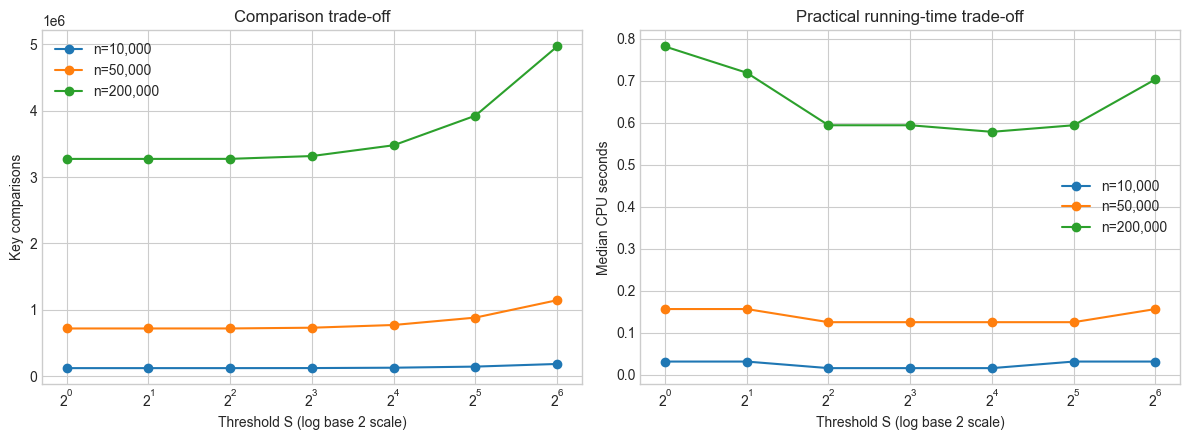

,n,time_best_S,median_cpu_seconds
2,10000,4,0.015625
9,50000,4,0.125000
18,200000,16,0.578125


,S,mean_relative_cpu_time,mean_comparisons
0,1,1.533784,1.370572e+06
1,2,1.497748,1.370572e+06
2,4,1.009009,1.370930e+06
3,8,1.009009,1.388981e+06
4,16,1.000000,1.458698e+06
5,32,1.342342,1.650086e+06
6,64,1.488739,2.098205e+06


Comparison-optimal candidate across these sizes: S = 1.
Practical CPU-time candidate selected for part (d): S = 16.
These values may differ because comparison count measures one algorithmic operation, whereas CPU time also reflects ordinary recursion, function-call, and loop overhead. The selection is evidence for this implementation and machine, not a universal constant.


In [7]:
SIZES_C3 = [10_000, 50_000, 200_000]
S_VALUES_C3 = [1, 2, 4, 8, 16, 32, 64]
CPU_REPETITIONS = 3

c3_rows = []
for n in SIZES_C3:
    data = make_dataset(n, SEED + 30_000_000 + n)
    for threshold in S_VALUES_C3:
        times = []
        comparison_count = None
        for _ in range(CPU_REPETITIONS):
            comparisons, cpu_seconds = run_sort(hybrid_merge_sort, data, threshold)
            comparison_count = comparisons
            times.append(cpu_seconds)
        c3_rows.append({
            "n": n,
            "S": threshold,
            "key_comparisons": comparison_count,
            "median_cpu_seconds": statistics.median(times),
        })
    del data
    gc.collect()

c3 = pd.DataFrame(c3_rows)
c3["relative_cpu_time"] = c3.groupby("n")["median_cpu_seconds"].transform(lambda x: x / x.min())
display(c3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for n, group in c3.groupby("n"):
    axes[0].plot(group["S"], group["key_comparisons"], marker="o", label=f"n={n:,}")
    axes[1].plot(group["S"], group["median_cpu_seconds"], marker="o", label=f"n={n:,}")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Threshold S (log base 2 scale)")
    ax.legend()
axes[0].set_ylabel("Key comparisons")
axes[0].set_title("Comparison trade-off")
axes[1].set_ylabel("Median CPU seconds")
axes[1].set_title("Practical running-time trade-off")
plt.tight_layout()
plt.show()

best_by_n = c3.loc[c3.groupby("n")["median_cpu_seconds"].idxmin(), ["n", "S", "median_cpu_seconds"]]
display(best_by_n.rename(columns={"S": "time_best_S"}))

threshold_summary = c3.groupby("S", as_index=False).agg(
    mean_relative_cpu_time=("relative_cpu_time", "mean"),
    mean_comparisons=("key_comparisons", "mean"),
)
selected_s = int(threshold_summary.loc[threshold_summary["mean_relative_cpu_time"].idxmin(), "S"])
comparison_selected_s = int(threshold_summary.loc[threshold_summary["mean_comparisons"].idxmin(), "S"])
display(threshold_summary)

print(f"Comparison-optimal candidate across these sizes: S = {comparison_selected_s}.")
print(f"Practical CPU-time candidate selected for part (d): S = {selected_s}.")
print(
    "These values may differ because comparison count measures one algorithmic operation, "
    "whereas CPU time also reflects ordinary recursion, function-call, and loop overhead. "
    "The selection is evidence for this implementation and machine, not a universal constant."
)


## (d) Original Merge Sort versus hybrid sort on 10,000,000 integers

Both algorithms sort copies of one shared random dataset. They use the same `merge` function and auxiliary-array strategy; the hybrid receives the practical threshold selected in part (c)(iii). The table reports the two quantities explicitly required by the project: key comparisons and CPU time.

This cell is intentionally expensive but bounded: one measured run of each textbook-style algorithm. Memory is reclaimed between runs where possible.


In [8]:
N_FINAL = 10_000_000
final_data = make_dataset(N_FINAL, SEED + 40_000_000)

final_rows = []
merge_comparisons, merge_cpu = run_sort(merge_sort, final_data)
final_rows.append({
    "algorithm": "Original Merge Sort",
    "n": N_FINAL,
    "S": None,
    "key_comparisons": merge_comparisons,
    "cpu_seconds": merge_cpu,
})
gc.collect()

hybrid_comparisons, hybrid_cpu = run_sort(hybrid_merge_sort, final_data, selected_s)
final_rows.append({
    "algorithm": "Hybrid Merge/Insertion Sort",
    "n": N_FINAL,
    "S": selected_s,
    "key_comparisons": hybrid_comparisons,
    "cpu_seconds": hybrid_cpu,
})

final_results = pd.DataFrame(final_rows)
display(final_results)

comparison_change = 100 * (hybrid_comparisons - merge_comparisons) / merge_comparisons
cpu_change = 100 * (hybrid_cpu - merge_cpu) / merge_cpu

print(f"Selected S: {selected_s}")
print(f"Hybrid comparison-count change versus Merge Sort: {comparison_change:+.2f}%")
print(f"Hybrid CPU-time change versus Merge Sort: {cpu_change:+.2f}%")

if hybrid_comparisons < merge_comparisons:
    comparison_statement = "used fewer"
else:
    comparison_statement = "used more"
if hybrid_cpu < merge_cpu:
    time_statement = "was faster"
else:
    time_statement = "was slower"

print(
    f"Conclusion for this dataset and environment: the hybrid {comparison_statement} key "
    f"comparisons and {time_statement} in CPU time. This does not change the shared "
    "Theta(n log n) asymptotic class; it demonstrates the constant-factor trade-off created "
    "by stopping recursion at S and using insertion sort on small subarrays."
)

del final_data
gc.collect()


,algorithm,n,S,key_comparisons,cpu_seconds
0,Original Merge Sort,10000000,NaN,220098332,60.578125
1,Hybrid Merge/Insertion Sort,10000000,16.0,226415036,53.921875


Selected S: 16
Hybrid comparison-count change versus Merge Sort: +2.87%
Hybrid CPU-time change versus Merge Sort: -10.99%
Conclusion for this dataset and environment: the hybrid used more key comparisons and was faster in CPU time. This does not change the shared Theta(n log n) asymptotic class; it demonstrates the constant-factor trade-off created by stopping recursion at S and using insertion sort on small subarrays.


8

## Final conclusions

1. The hybrid algorithm retains the $\Theta(n\log n)$ growth of Merge Sort when $S$ is a fixed small constant.
2. Its comparison model is $\Theta(n\log(n/S)+nS)$: increasing $S$ removes merge levels but increases insertion-sort work inside the leaves.
3. For key comparisons alone, a very small $S$ is usually preferable on random input. For CPU time, a somewhat larger $S$ can be faster because it avoids recursive-call and small-merge overhead.
4. An appropriate practical $S$ should be chosen from repeated measurements across several representative input sizes, while clearly reporting that the selected value is implementation- and environment-dependent.
5. The 10-million-element comparison uses identical input and structurally comparable algorithms, so its observed differences are attributable to the threshold/base-case choice rather than unequal optimisation.

### Presentation-ready points

- Define exactly what counts as a key comparison.
- Show the one-line conceptual difference between the algorithms.
- Explain the two competing terms in $\Theta(n\log(n/S)+nS)$.
- Use the part (c) plots to justify the chosen $S$.
- Report both required part (d) measurements and distinguish empirical constants from asymptotic growth.
